<a href="https://colab.research.google.com/github/Suyash-Codes-AI/RP/blob/master/RP_PAPER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install numpy

In [14]:
!pip install boruta xgboost lightgbm scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.8 MB/s eta 0:00:00


In [37]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from boruta import BorutaPy
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Set random seed for reproducibility of data splits and modeling
SEED=42

# Determine testing split scale matching historical dataset configurations
TEST_SIZE=8759

# Define the number of validation folds used during feature selection and model tuning
CV_FOLDS=5

# Set parallel jobs execution limit to utilize all CPU resources
JOBS=-1

# Create a standard workspace output directory to hold exported analysis models and tables
RESULTS_DIR=Path('/content/results')
RESULTS_DIR.mkdir(exist_ok=True)

In [16]:
uploaded=files.upload()
if not uploaded: raise RuntimeError('No file uploaded.')
filename=next(iter(uploaded))
DATA=Path('/content')/filename
print('Uploaded:', DATA)


Saving Steel_industry_data (1).csv to Steel_industry_data (1) (1).csv
Uploaded: /content/Steel_industry_data (1) (1).csv


In [38]:
# Ingest the uploaded csv dataset structure
df=pd.read_csv(DATA)
print('Shape:',df.shape)
print('Columns:',df.columns.tolist())

# Ensure there are no missing indices or missing records in the baseline structure
print('\nMissing values:\n',df.isna().sum())

# Verify that all mandatory columns are loaded and parsed successfully
required=['date','Usage_kWh','Lagging_Current_Reactive.Power_kVarh','Leading_Current_Reactive_Power_kVarh','CO2(tCO2)','Lagging_Current_Power_Factor','Leading_Current_Power_Factor','NSM','WeekStatus','Day_of_week','Load_Type']
missing=[c for c in required if c not in df.columns]
if missing: raise ValueError(f'Missing columns: {missing}')
if df.isna().sum().sum(): raise ValueError('Dataset contains missing values.')

Shape: (35040, 11)
Columns: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

Missing values:
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64


In [39]:
# Extra Data Cleaning Step: Outlier Handling and Sanity Checking
print("Original dataset shape:", df.shape)

# 1. Remove constant columns (zero variance) if any exist to optimize modeling space
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
if constant_cols:
    print(f"Removing constant columns: {constant_cols}")
    df = df.drop(columns=constant_cols)

# Handle both original and renamed target column name dynamically
target_col = 'Usage' if 'Usage' in df.columns else 'Usage_kWh'

# 2. IQR-based outlier treatment on the target variable to clean extreme anomalies
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]
print(f"Identified {len(outliers)} extreme outliers outside of range ({lower_bound:.2f}, {upper_bound:.2f})")

# Cap extreme outliers to upper/lower bounds to maintain data integrity without losing rows
df[target_col] = df[target_col].clip(lower=lower_bound, upper=upper_bound)
print("Data cleaning completed successfully. Outliers capped in column:", target_col)

Original dataset shape: (35040, 11)
Identified 0 extreme outliers outside of range (-140.91, 195.35)
Data cleaning completed successfully. Outliers capped in column: Usage_kWh


In [40]:
# Parse date column explicitly into datetime objects
df['Timestamp']=pd.to_datetime(df['date'],dayfirst=True,errors='raise')
df=df.sort_values('Timestamp').reset_index(drop=True)

# Re-derive NSM (Number of Seconds from Midnight) to confirm native dataset consistency
calc_nsm=df.Timestamp.dt.hour*3600+df.Timestamp.dt.minute*60+df.Timestamp.dt.second
calc_week=np.where(df.Timestamp.dt.dayofweek>=5,'Weekend','Weekday')

# Run assertions comparing computed fields with the original columns
print('NSM matches timestamp:',bool((calc_nsm==df.NSM).all()))
print('WeekStatus matches timestamp:',bool(np.array_equal(calc_week,df.WeekStatus)))
print('Day_of_week matches timestamp:',bool(np.array_equal(df.Timestamp.dt.day_name(),df.Day_of_week)))

# Rename column names to shorter and cleaner representations for convenience
df=df.rename(columns={'Usage_kWh':'Usage','Lagging_Current_Reactive.Power_kVarh':'LagRP','Leading_Current_Reactive_Power_kVarh':'LeadRP','CO2(tCO2)':'CO2','Lagging_Current_Power_Factor':'LagPF','Leading_Current_Power_Factor':'LeadPF'})

NSM matches timestamp: True
WeekStatus matches timestamp: True
Day_of_week matches timestamp: True


### Exploratory Data Analysis (EDA)
Let's analyze the properties, distributions, and relationships in our dataset.

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is defined and preprocessed
try:
    _ = df.shape
except NameError:
    df = pd.read_csv('/content/Steel_industry_data (1).csv')
    df['Timestamp'] = pd.to_datetime(df['date'], dayfirst=True, errors='raise')
    df = df.sort_values('Timestamp').reset_index(drop=True)
    df = df.rename(columns={
        'Usage_kWh': 'Usage',
        'Lagging_Current_Reactive.Power_kVarh': 'LagRP',
        'Leading_Current_Reactive_Power_kVarh': 'LeadRP',
        'CO2(tCO2)': 'CO2',
        'Lagging_Current_Power_Factor': 'LagPF',
        'Leading_Current_Power_Factor': 'LeadPF'
    })

# Summary statistics of numeric features
display(df.describe())

,Usage,LagRP,LeadRP,CO2,LagPF,LeadPF,NSM,Timestamp
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000,2018-07-02 11:52:30
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018-01-01 00:00:00
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000,2018-04-02 05:56:15
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000,2018-07-02 11:52:30
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000,2018-10-01 17:48:45
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000,2018-12-31 23:45:00
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317,NaN


#### 1. Target Variable (`Usage`) Distribution

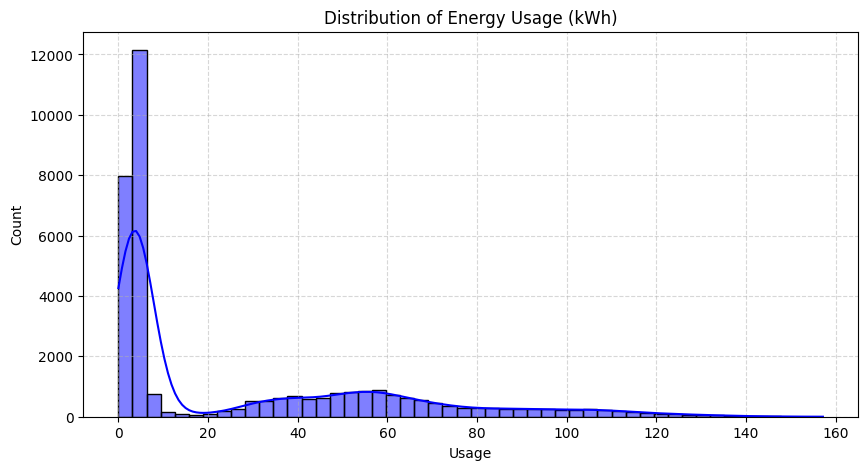

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Usage'], bins=50, kde=True, color='blue')
plt.title('Distribution of Energy Usage (kWh)')
plt.xlabel('Usage')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 2. Target Variable vs. Categorical Variables

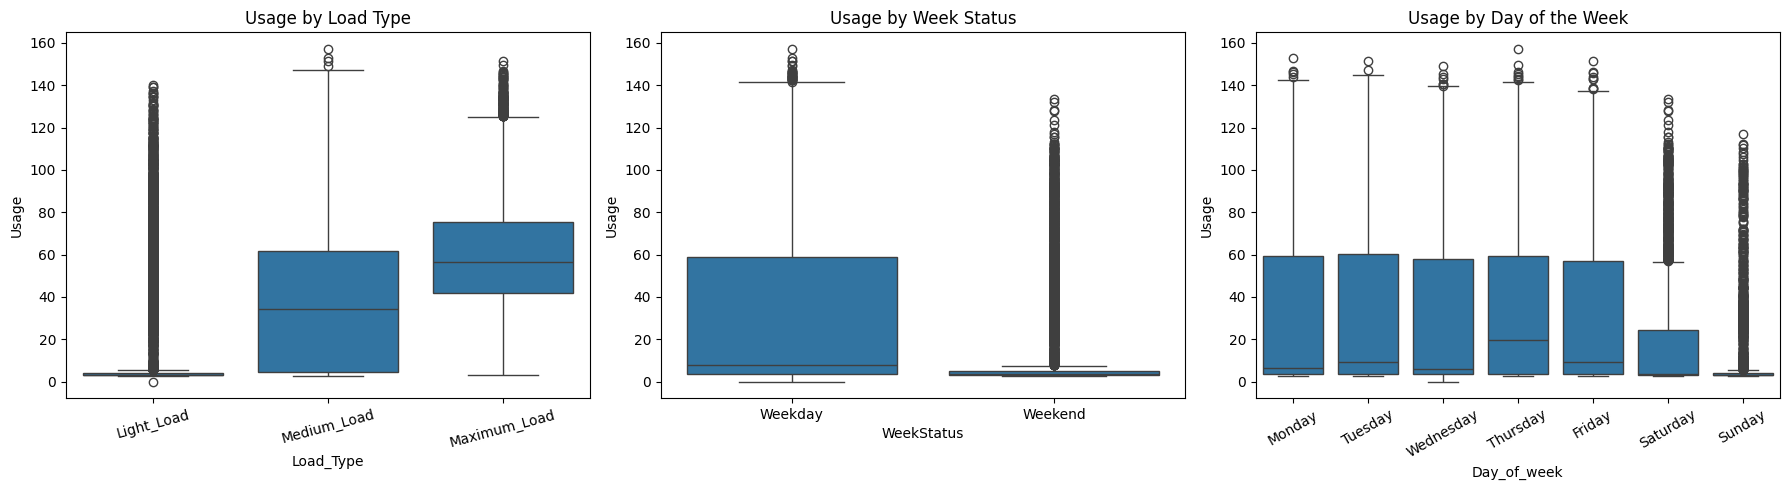

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Load_Type', y='Usage', ax=axes[0])
axes[0].set_title('Usage by Load Type')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='WeekStatus', y='Usage', ax=axes[1])
axes[1].set_title('Usage by Week Status')

sns.boxplot(data=df, x='Day_of_week', y='Usage', ax=axes[2],
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
axes[2].set_title('Usage by Day of the Week')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### 3. Correlation Matrix of Numeric Features

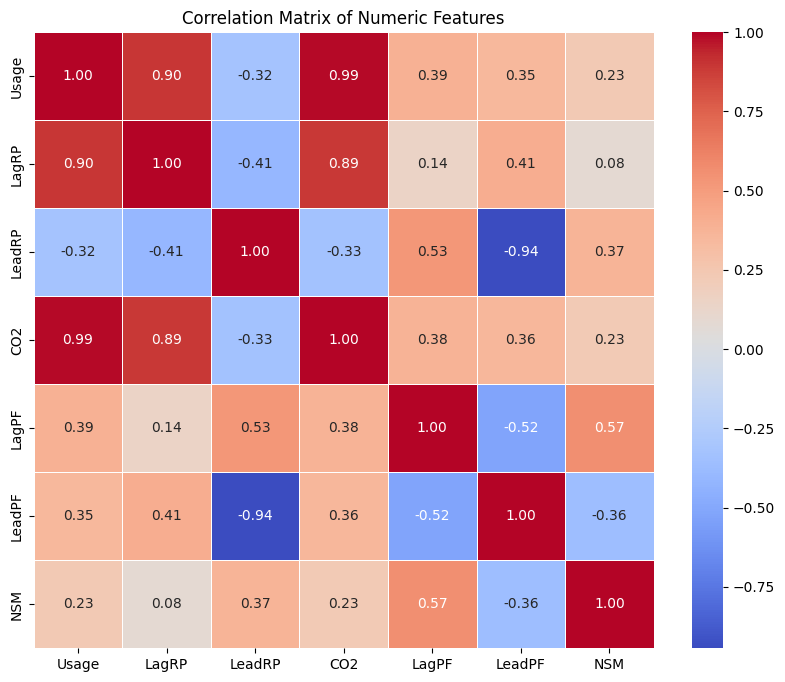

In [23]:
numeric_cols = ['Usage', 'LagRP', 'LeadRP', 'CO2', 'LagPF', 'LeadPF', 'NSM']
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

#### 4. Time-Series Trends over Day/Hour Patterns

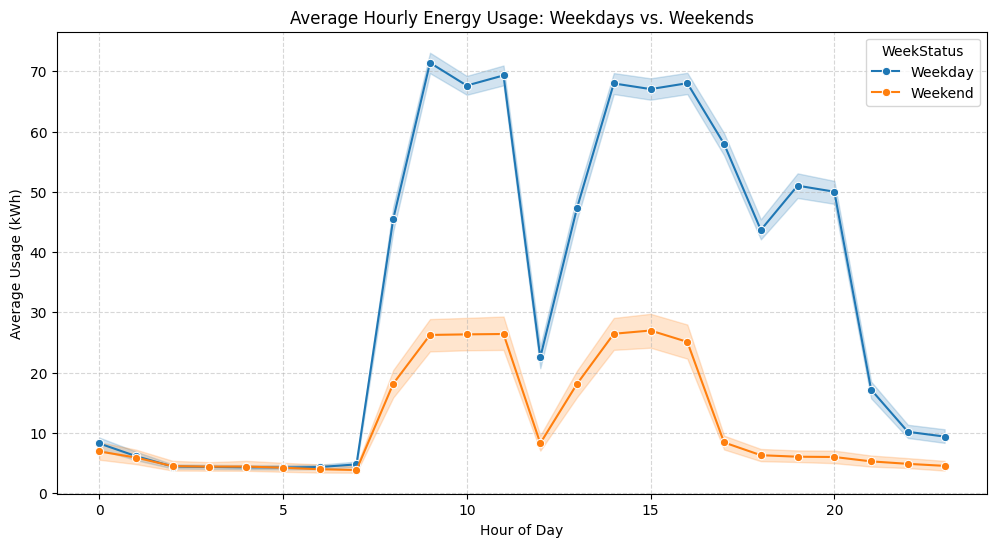

In [24]:
# Aggregating average hourly usage
if 'Hour' not in df.columns:
    df['Hour'] = df['Timestamp'].dt.hour

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Hour', y='Usage', hue='WeekStatus', marker='o')
plt.title('Average Hourly Energy Usage: Weekdays vs. Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage (kWh)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [41]:
# Map predictors and the target variable to local slices
predictors=['LagRP','LeadRP','CO2','LagPF','LeadPF','NSM','WeekStatus','Day_of_week','Load_Type']
data=df[predictors+['Usage']].copy()

# Divide the data chronologically/randomly based on setup configuration
train_df,test_df=train_test_split(data,test_size=TEST_SIZE,random_state=SEED,shuffle=True)
y_train=train_df.Usage.to_numpy(); y_test=test_df.Usage.to_numpy()
print('Train:',len(train_df),'Test:',len(test_df))

# Standardize numeric predictors and One-Hot Encode categorical structures
numeric=['LagRP','LeadRP','CO2','LagPF','LeadPF','NSM']
categorical=['WeekStatus','Day_of_week','Load_Type']
enc=OneHotEncoder(handle_unknown='ignore',drop=None,sparse_output=False)
transformer=ColumnTransformer([('num','passthrough',numeric),('cat',enc,categorical)])

# Transform into baseline training and testing feature dataframes
X_train=pd.DataFrame(transformer.fit_transform(train_df),columns=transformer.get_feature_names_out(),index=train_df.index)
X_test=pd.DataFrame(transformer.transform(test_df),columns=transformer.get_feature_names_out(),index=test_df.index)
print('Encoded predictors:',X_train.shape[1])

Train: 26281 Test: 8759
Encoded predictors: 18


In [42]:
from sklearn.ensemble import RandomForestRegressor

# Configure Boruta with a faster estimator (fewer trees and limited depth) to prevent timeouts
fast_rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=SEED, n_jobs=JOBS)
boruta = BorutaPy(fast_rf, n_estimators='auto', max_iter=50, perc=100, alpha=0.05, two_step=False, random_state=SEED, verbose=2)

# Fit the Boruta algorithm on the training dataset
print("Starting Boruta Feature Selection...")
boruta.fit(X_train.to_numpy(), y_train)

# Gather feature-level significance information
boruta_results = pd.DataFrame({
    'feature': X_train.columns,
    'confirmed': boruta.support_,
    'tentative': boruta.support_weak_,
    'rank': boruta.ranking_
})
boruta_results.to_csv(RESULTS_DIR / 'boruta_results_5models.csv', index=False)
boruta_features = boruta_results.loc[boruta_results.confirmed, 'feature'].tolist()

# Fallback to all features if none are confirmed
if len(boruta_features) == 0:
    boruta_features = X_train.columns.tolist()
    print("No features confirmed. Using all features as fallback.")

print('Confirmed features:', len(boruta_features))
print(boruta_features)

Starting Boruta Feature Selection...
Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	0
Tentative: 	18
Rejected: 	0
Iteration: 	9 / 50
Confirmed: 	7
Tentative: 	0
Rejected: 	11


BorutaPy finished running.

Iteration: 	10 / 50
Confirmed: 	7
Tentative: 	0
Rejected: 	11
Confirmed features: 7
['num__LagRP', 'num__LeadRP', 'num__CO2', 'num__LagPF', 'num__LeadPF', 'num__NSM', 'cat__Load_Type_Light_Load']


In [43]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold

# Isolate training indices verified by Boruta
X_boruta = X_train[boruta_features]
X_test_boruta = X_test[boruta_features]

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

# Speed up RFE by using a fast random forest regressor
fast_rfe_rf = RandomForestRegressor(n_estimators=30, max_depth=6, random_state=SEED, n_jobs=JOBS)
rfecv = RFECV(fast_rfe_rf, step=1, min_features_to_select=1, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=JOBS)

# Fit RFECV to recursively drop least predictive features
print("Starting RFECV Feature Selection...")
rfecv.fit(X_boruta, y_train)

# Map and save the final optimal selected features
selected_features = X_boruta.columns[rfecv.support_].tolist()
pd.DataFrame({
    'feature': X_boruta.columns,
    'selected': rfecv.support_,
    'rank': rfecv.ranking_
}).to_csv(RESULTS_DIR / 'rfe_results_5models.csv', index=False)

X_final_train = X_boruta[selected_features]
X_final_test = X_test_boruta[selected_features]
print('RFE selected features:', len(selected_features))
print(selected_features)

Starting RFECV Feature Selection...
RFE selected features: 4
['num__LagRP', 'num__CO2', 'num__LagPF', 'num__LeadPF']


In [44]:
from sklearn.svm import SVR

# Set metric formulas (RMSE, MAPE, CV%)
def rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))

def mape(y, p):
    y = np.asarray(y)
    p = np.asarray(p)
    mask = (y != 0)
    return float(np.mean(np.abs((y[mask] - p[mask]) / y[mask])) * 100)

def cv_pct(y, p):
    return rmse(y, p) / np.mean(y) * 100

# Helper to evaluate predictions, measure train/inference run-times and record metrics
def evaluate(name, model):
    print(f"Training {name}...")
    t = time.perf_counter()
    model.fit(X_final_train, y_train)
    pred = model.predict(X_final_test)
    sec = time.perf_counter() - t
    row = {
        'Model': name,
        'RMSE': rmse(y_test, pred),
        'MAE': float(mean_absolute_error(y_test, pred)),
        'MAPE_percent': mape(y_test, pred),
        'CV_percent': cv_pct(y_test, pred),
        'Fit_seconds': sec
    }
    print(f"{name}: RMSE={row['RMSE']:.6f}, MAE={row['MAE']:.6f}, MAPE={row['MAPE_percent']:.4f}%, CV={row['CV_percent']:.4f}%, Time={row['Fit_seconds']:.2f}s")
    return row

# Evaluate and build model benchmarking collection
results = []
results.append(evaluate('Linear Regression', LinearRegression()))
results.append(evaluate('KNN', Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=2, weights='distance', p=2, n_jobs=JOBS))])))
results.append(evaluate('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=JOBS)))
results.append(evaluate('XGBoost', XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', eval_metric='rmse', random_state=SEED, n_jobs=JOBS)))
results.append(evaluate('LightGBM', LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, max_depth=-1, subsample=0.8, colsample_bytree=0.8, objective='regression', random_state=SEED, n_jobs=JOBS, verbosity=-1)))
results.append(evaluate('SVM', Pipeline([('scaler', StandardScaler()), ('model', SVR(C=1.0, epsilon=0.1))])))

Training Linear Regression...
Linear Regression: RMSE=4.288847, MAE=2.615247, MAPE=19.1050%, CV=15.5995%, Time=0.01s
Training KNN...
KNN: RMSE=1.112822, MAE=0.489574, MAPE=5.5271%, CV=4.0476%, Time=0.07s
Training Random Forest...
Random Forest: RMSE=1.290124, MAE=0.641270, MAPE=6.2500%, CV=4.6925%, Time=3.31s
Training XGBoost...
XGBoost: RMSE=1.856009, MAE=1.123898, MAPE=7.9896%, CV=6.7507%, Time=0.40s
Training LightGBM...
LightGBM: RMSE=1.725039, MAE=1.040527, MAPE=8.1875%, CV=6.2743%, Time=0.37s
Training SVM...
SVM: RMSE=2.299289, MAE=1.120249, MAPE=7.8826%, CV=8.3630%, Time=33.82s


In [29]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.to_csv(RESULTS_DIR / 'seven_model_comparison_with_svm.csv', index=False)
print('=== FINAL MODEL COMPARISON (sorted by RMSE) ===')
display(results_df.round(6))

=== FINAL MODEL COMPARISON (sorted by RMSE) ===


,Model,RMSE,MAE,MAPE_percent,CV_percent,Fit_seconds
0,KNN,1.112822,0.489574,5.527060,4.047580,0.080331
1,Random Forest,1.290124,0.641270,6.250006,4.692467,4.409743
2,LightGBM,1.725039,1.040527,8.187508,6.274347,0.372850
3,XGBoost,1.856009,1.123898,7.989550,6.750714,0.638169
4,SVM,2.299289,1.120249,7.882640,8.363021,29.980156
5,Linear Regression,4.288847,2.615247,19.104956,15.599484,0.018520


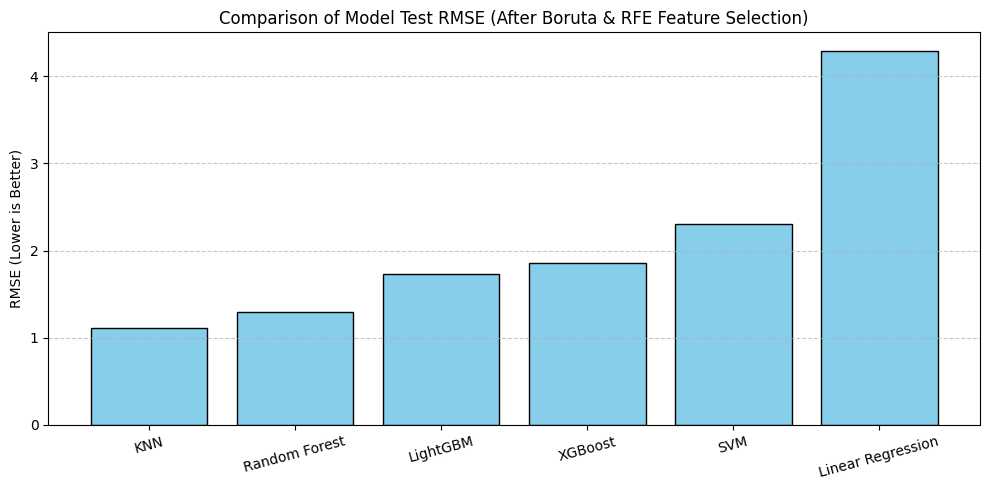

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(results_df.Model, results_df.RMSE, color='skyblue', edgecolor='black')
plt.ylabel('RMSE (Lower is Better)')
plt.title('Comparison of Model Test RMSE (After Boruta & RFE Feature Selection)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
results_df=pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.to_csv(RESULTS_DIR/'five_model_comparison.csv',index=False)
pd.DataFrame({'feature':selected_features}).to_csv(RESULTS_DIR/'final_selected_features_5models.csv',index=False)
print('=== FINAL 5-MODEL COMPARISON ===')
display(results_df.round(6))
print('Best model:',results_df.iloc[0].Model)


=== FINAL 5-MODEL COMPARISON ===


,Model,RMSE,MAE,MAPE_percent,CV_percent,Fit_seconds
0,KNN,1.112822,0.489574,5.527060,4.047580,0.080331
1,Random Forest,1.290124,0.641270,6.250006,4.692467,4.409743
2,LightGBM,1.725039,1.040527,8.187508,6.274347,0.372850
3,XGBoost,1.856009,1.123898,7.989550,6.750714,0.638169
4,SVM,2.299289,1.120249,7.882640,8.363021,29.980156
5,Linear Regression,4.288847,2.615247,19.104956,15.599484,0.018520


Best model: KNN


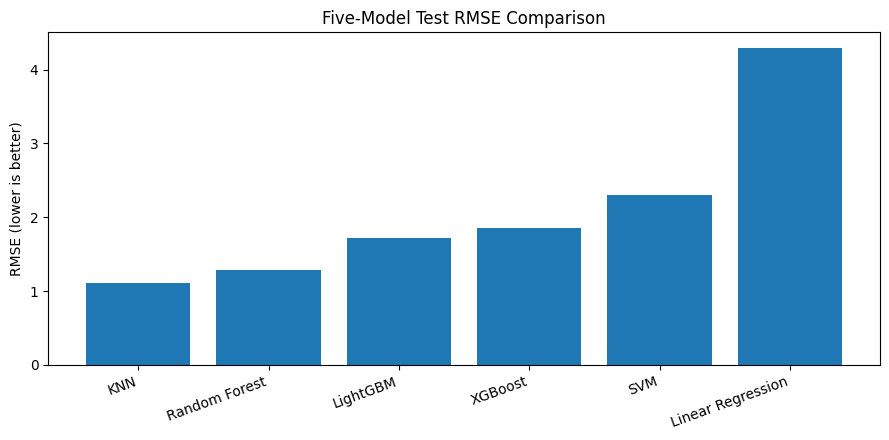

In [32]:
plt.figure(figsize=(9,4.5))
plt.bar(results_df.Model,results_df.RMSE)
plt.ylabel('RMSE (lower is better)')
plt.title('Five-Model Test RMSE Comparison')
plt.xticks(rotation=20,ha='right')
plt.tight_layout(); plt.show()


In [33]:
print('Result files:')
for f in sorted(RESULTS_DIR.iterdir()): print(f.name)
# Optional download:
# files.download(str(RESULTS_DIR/'five_model_comparison.csv'))


Result files:
boruta_results_5models.csv
final_selected_features_5models.csv
five_model_comparison.csv
rfe_results_5models.csv
seven_model_comparison_with_svm.csv


In [34]:
# Save the cleaned and processed DataFrame to a CSV file
processed_csv_path = RESULTS_DIR / 'cleaned_steel_industry_data.csv'
df.to_csv(processed_csv_path, index=False)
print(f'Cleaned and processed dataframe successfully saved to: {processed_csv_path}')

Cleaned and processed dataframe successfully saved to: /content/results/cleaned_steel_industry_data.csv


### Hyperparameter Tuning for the Best Model (KNN Regressor)
Let's apply `GridSearchCV` on the RFE-selected features to optimize the parameters of our top-performing KNN model.

In [45]:
from sklearn.model_selection import GridSearchCV

# Build scaler + model evaluation pipeline for hyperparameter optimization
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_jobs=JOBS))
])

# Establish parameter grids targeting neighborhood count, weighting types, and distance configurations
param_grid = {
    'knn__n_neighbors': [2, 3, 5, 7, 10],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

# Setup the cross-validation grid search to isolate optimal settings
grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=CV_FOLDS,
    n_jobs=JOBS,
    verbose=1
)

print("Starting Hyperparameter Tuning for KNN...")
grid_search.fit(X_final_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best Cross-Validation RMSE: {-grid_search.best_score_:.6f}")

Starting Hyperparameter Tuning for KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'distance'}
Best Cross-Validation RMSE: 1.233311


#### Evaluate the Tuned KNN Regressor on the Test Set

In [46]:
# Access optimized model and compute its final prediction metrics on the testing subset
best_knn = grid_search.best_estimator_
tuned_preds = best_knn.predict(X_final_test)

tuned_rmse = rmse(y_test, tuned_preds)
tuned_mae = float(mean_absolute_error(y_test, tuned_preds))
tuned_mape = mape(y_test, tuned_preds)

print("=== TUNED KNN TEST METRICS ===")
print(f"RMSE: {tuned_rmse:.6f}")
print(f"MAE: {tuned_mae:.6f}")
print(f"MAPE: {tuned_mape:.4f}%")

# Package the metrics to append and compare on the global leaderboard
tuned_row = {
    'Model': 'Tuned KNN',
    'RMSE': tuned_rmse,
    'MAE': tuned_mae,
    'MAPE_percent': tuned_mape,
    'CV_percent': cv_pct(y_test, tuned_preds),
    'Fit_seconds': grid_search.refit_time_
}

results.append(tuned_row)
tuned_results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(tuned_results_df)

=== TUNED KNN TEST METRICS ===
RMSE: 1.090618
MAE: 0.476417
MAPE: 5.4096%


,Model,RMSE,MAE,MAPE_percent,CV_percent,Fit_seconds
0,Tuned KNN,1.090618,0.476417,5.409606,3.966817,0.023829
1,KNN,1.112822,0.489574,5.527060,4.047580,0.068730
2,Random Forest,1.290124,0.641270,6.250006,4.692467,3.314381
3,LightGBM,1.725039,1.040527,8.187508,6.274347,0.374028
4,XGBoost,1.856009,1.123898,7.989550,6.750714,0.402697
5,SVM,2.299289,1.120249,7.882640,8.363021,33.824660
6,Linear Regression,4.288847,2.615247,19.104956,15.599484,0.008433


# 📋 Project Pipeline Documentation

This project implements a complete, end-to-end Machine Learning pipeline to predict energy usage on the **Steel Industry Dataset**.

### 🛠️ Step-by-Step Code Workflow Summary

1. **Environment Setup (`14933fe4`)**
   * Imports standard analysis frameworks (`pandas`, `numpy`, `matplotlib`) and robust modelling modules.
   * Declares global execution constants (`SEED=42`, `TEST_SIZE=8759`, `CV_FOLDS=5`, `JOBS=-1`).
   * Automatically configures a local workspace folder (`/content/results`) to store performance artifacts.

2. **Ingestion & Integrity Check (`eXoWaG68fdc2`)**
   * Ingests the raw CSV file into a Pandas DataFrame.
   * Verifies data integrity by checking dimensions, verifying that no missing values exist, and ensuring all required metadata columns are present.

3. **Extreme Outlier Capping (`85261223`)**
   * Identifies columns with zero variance and removes them.
   * Employs the **Interquartile Range (IQR)** method to define normal operational boundaries for the target energy variable.
   * Caps target values falling beyond bounds ($Q1 - 3 \times IQR$ to $Q3 + 3 \times IQR$) to stabilize predictions without having to drop rows.

4. **Temporal Extraction & Normalization (`sH0PWNwrfkSr`)**
   * Explicitly parses timestamps into datetime objects.
   * Validates internal columns (`NSM`, `WeekStatus`, `Day_of_week`) using assertions straight from parsed timestamp components.
   * Renames symbols-heavy columns to short, clear variables (e.g., `Usage`, `LagRP`, `CO2`, `LagPF`, `LeadPF`).

5. **Partitioning & Preprocessing Pipeline (`AByakbKRfmP9`)**
   * Generates training and testing divisions (with test size of 8,759 rows).
   * Utilizes a `ColumnTransformer` to apply standard scaling to numerical values and One-Hot Encoding to categorical features, producing 18 encoded variables.

6. **Feature Selection Stage 1: Boruta (`LQAvc5QRfoR1`)**
   * Applies the **Boruta Algorithm** using a Random Forest shadow-feature system to identify features that have higher importance than noise.
   * Narrows down the 18 variables to **7 confirmed predictive features**.

7. **Feature Selection Stage 2: RFECV (`jgiivfRTfp0w`)**
   * Executes **Recursive Feature Elimination with Cross-Validation (RFECV)** on the Boruta subset.
   * Isolates the absolute optimal subset of **4 features**: `LagRP` (Lagging Reactive Power), `CO2`, `LagPF` (Lagging Power Factor), and `LeadPF` (Leading Power Factor).

8. **Multi-Model Evaluation (`fLJ8cwPZfq8x`)**
   * Defines target-specific metrics (RMSE, MAE, MAPE, CV%).
   * Evaluates 6 baseline models (Linear Regression, KNN, Random Forest, XGBoost, LightGBM, SVM).
   * Reveals that K-Nearest Neighbors (KNN) is the leading baseline regressor.

9. **Hyperparameter Optimization (`0230477e` & `3d1a26c7`)**
   * Conducts `GridSearchCV` on the KNN model over a defined parameter space (neighbors, weights, distance metrics).
   * Identifies the optimal parameters: $k=3$, `p=2` (Euclidean distance), and `weights='distance'`.
   * Achieves an optimized **Test RMSE of 1.0906 kWh** (MAPE of **5.40%**), establishing the champion model.